In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load datset

In [2]:
df = pd.read_csv("D:/Local Y/project41/dataset/Unemployment in India.csv")

df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)

df.head()


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


### Basic dataset inspetion

In [3]:
print("Shape:",df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

Shape: (754, 7)

Columns
Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Data Types:
Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
dtype: object

Missing Values:
Region                                     14
Date                                       14
Frequency                                  14
Estimated Unemployment Rate (%)            14
Estimated Employed                         14
Estimated Labour Participation Rate (%)    14
Area                                       14
dtype: int64

Duplic

### Data Cleaning

In [4]:
# remove completely empty rows

df = df.dropna(how="all")

df = df.dropna(subset=['Region','Date','Estimated Unemployment Rate (%)'])

df["Region"] = df["Region"].str.strip()
df["Frequency"] = df["Frequency"].str.strip()
df["Area"] = df["Area"].str.strip()

print("Cleaned shape:",df.shape)

Cleaned shape: (740, 7)


### Overall Unemployment Trends

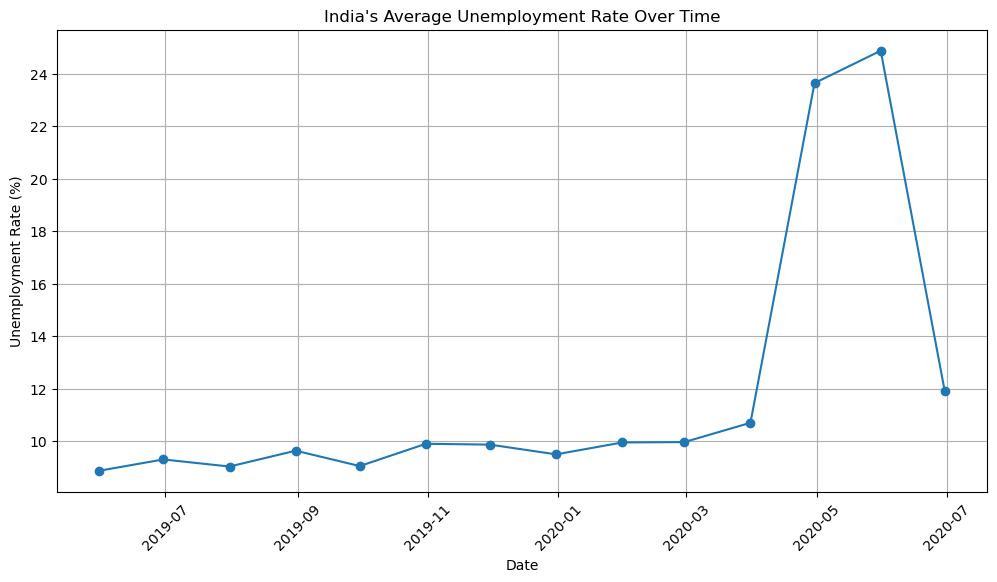

In [5]:
monthly_Unemployment = (df.groupby("Date")["Estimated Unemployment Rate (%)"].mean().reset_index())

plt.figure(figsize=(12,6))
plt.plot(monthly_Unemployment["Date"],
         monthly_Unemployment["Estimated Unemployment Rate (%)"],
         marker='o'
         )
plt.title("India's Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Covid19 impact analysis

In [6]:
df["Period"] = np.where(
    df["Date"] < "2020-03-01", "Pre-COVID",
    np.where(
        df["Date"] <= "2020-06-30",
        "COVID Period",
        "Post_Lockdown"
    )
)

period_analysis = (df.groupby("Period")["Estimated Unemployment Rate (%)"].mean().reset_index())

print(period_analysis)

         Period  Estimated Unemployment Rate (%)
0  COVID Period                        17.774363
1     Pre-COVID                         9.509534


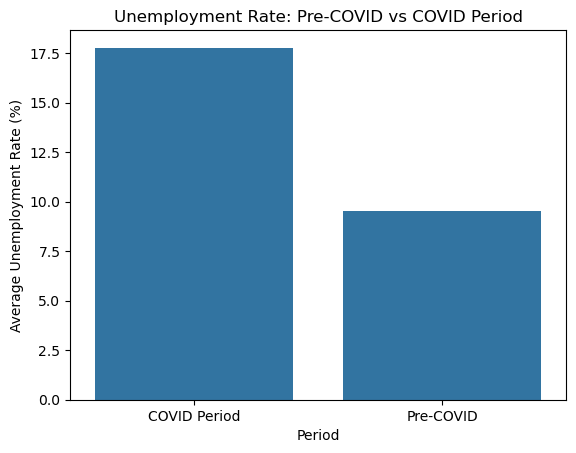

In [7]:
plt.Figure(figsize=(8,5))

sns.barplot(
    data=period_analysis,
    x="Period",
    y="Estimated Unemployment Rate (%)"    
)

plt.title("Unemployment Rate: Pre-COVID vs COVID Period")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

### COVID Monthly analysis

In [8]:
covid_monthly = (df[df["Date"] >= "2020-01-01"]
                 .groupby("Date")["Estimated Unemployment Rate (%)"]
                 .mean().reset_index()
                 )
print(covid_monthly)

        Date  Estimated Unemployment Rate (%)
0 2020-01-31                         9.950755
1 2020-02-29                         9.964717
2 2020-03-31                        10.700577
3 2020-04-30                        23.641569
4 2020-05-31                        24.875294
5 2020-06-30                        11.903600


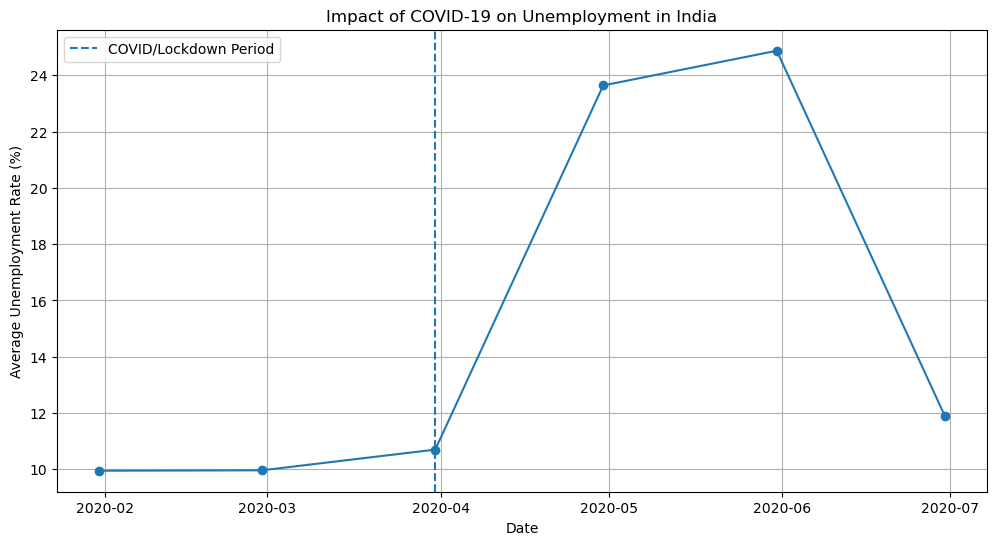

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    covid_monthly["Date"],
    covid_monthly["Estimated Unemployment Rate (%)"],
    marker="o"
)

plt.axvline(
    pd.Timestamp("2020-03-31"),
    linestyle="--",
    label="COVID/Lockdown Period"
)

plt.title("Impact of COVID-19 on Unemployment in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

### Rural vs Urban unemployment

In [10]:
area_analysis = (
    df.groupby("Area")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

print(area_analysis)

    Area  Estimated Unemployment Rate (%)
0  Rural                        10.324791
1  Urban                        13.166614


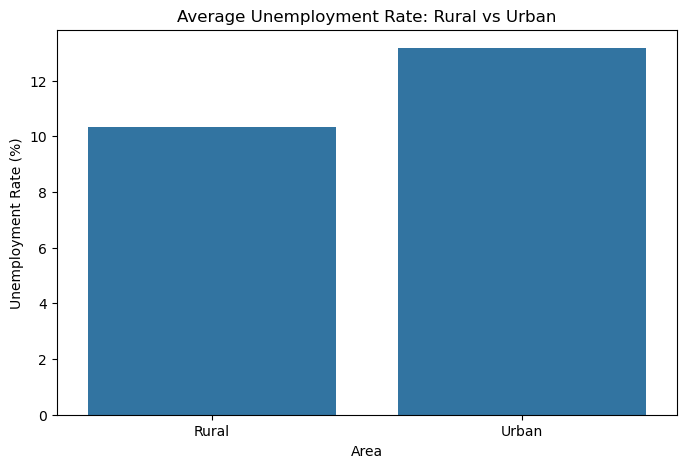

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=area_analysis,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Average Unemployment Rate: Rural vs Urban")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")

plt.show()

### Rural vs Urban COVID trend

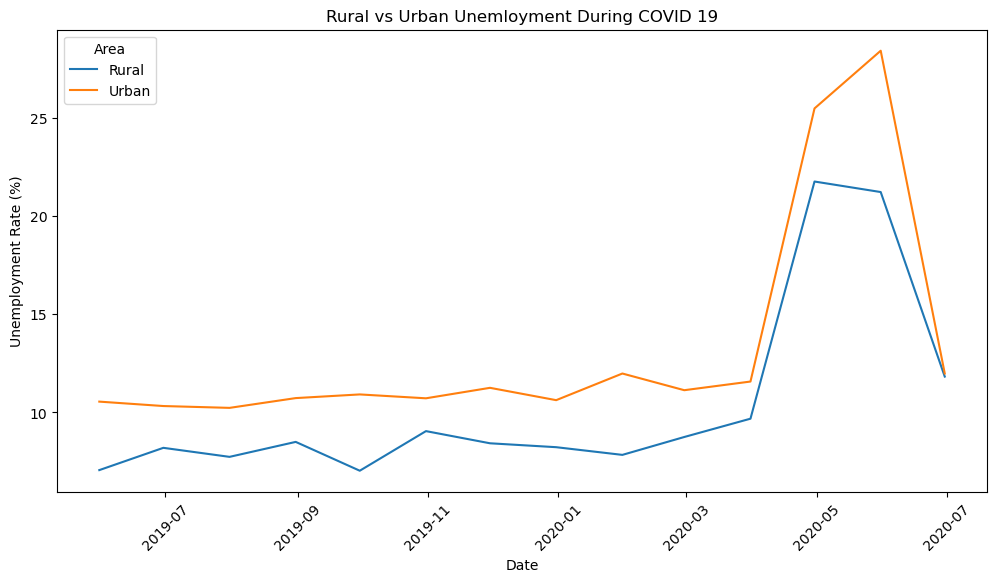

In [12]:
area_monthly = (df.groupby(["Date","Area"])["Estimated Unemployment Rate (%)"].mean().reset_index())

plt.figure(figsize=(12,6))

sns.lineplot(
    data=area_monthly,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Area",
    markers="o"
)

plt.title("Rural vs Urban Unemloyment During COVID 19")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.show()

### state-wise unemployment analysis

In [13]:
state_analysis = (df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False))

print(state_analysis)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


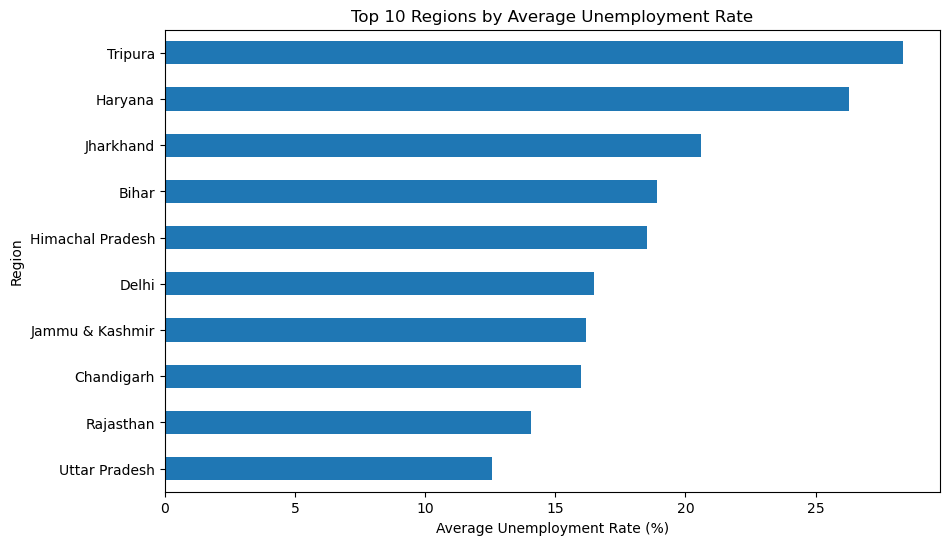

In [14]:
top10 = state_analysis.head(10)

plt.figure(figsize=(10,6))
top10.sort_values().plot(kind="barh")

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.show()

### State-wise COVID impact

In [15]:
pre_covid = (df[df["Date"] < "2020-03-01"].groupby("Region")["Estimated Unemployment Rate (%)"].mean())

covid = (
    df[
        (df["Date"] >= "2020-03-01") &
        (df["Date"] <= "2020-06-30")
    ]
    .groupby("Region")["Estimated Unemployment Rate (%)"].mean()
)

impact = pd.DataFrame({
    "Pre_COVID_Rate": pre_covid,
    "COVID_Rate": covid
})

impact["Change"] = (impact["COVID_Rate"] - impact["Pre_COVID_Rate"])

imapct = impact.sort_values("Change",ascending=False)

print(impact.head(10))


                  Pre_COVID_Rate  COVID_Rate    Change
Region                                                
Andhra Pradesh          5.037500   13.576250   8.53875
Assam                   6.372632    6.578571   0.20594
Bihar                  13.833000   31.631250  17.79825
Chandigarh             16.325000   14.325000  -2.00000
Chhattisgarh            7.706500   13.075000   5.36850
Delhi                  14.230500   22.157500   7.92700
Goa                     8.507500   13.107500   4.60000
Gujarat                 5.176000   10.383750   5.20775
Haryana                22.935500   34.652500  11.71700
Himachal Pradesh       19.129000   17.068750  -2.06025


### Employment trend

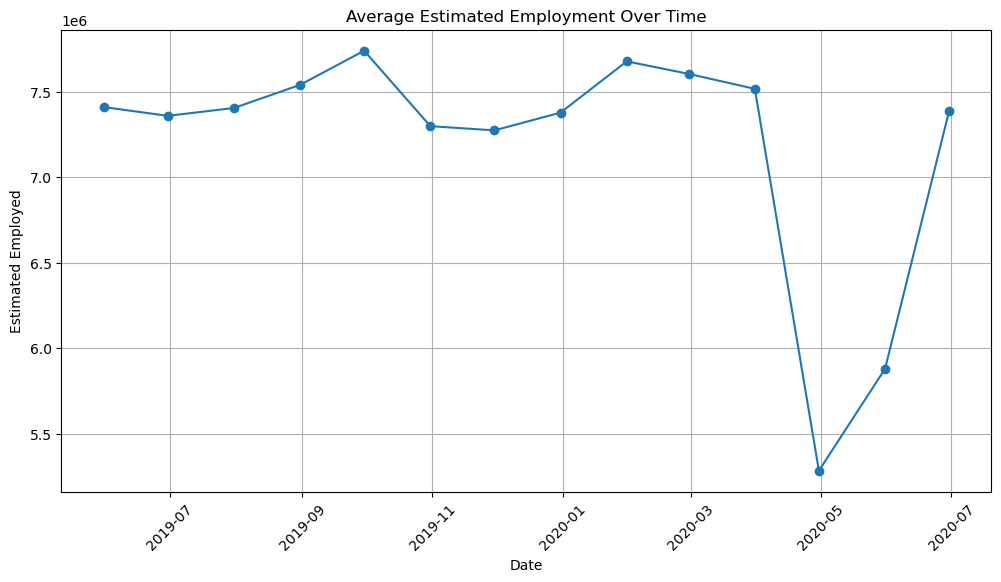

In [16]:
employment = (df.groupby("Date")["Estimated Employed"].mean().reset_index())

plt.figure(figsize=(12,6))
plt.plot(
    employment["Date"],
    employment["Estimated Employed"],
    marker="o"
)

plt.title("Average Estimated Employment Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Employed")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Labour participation rate

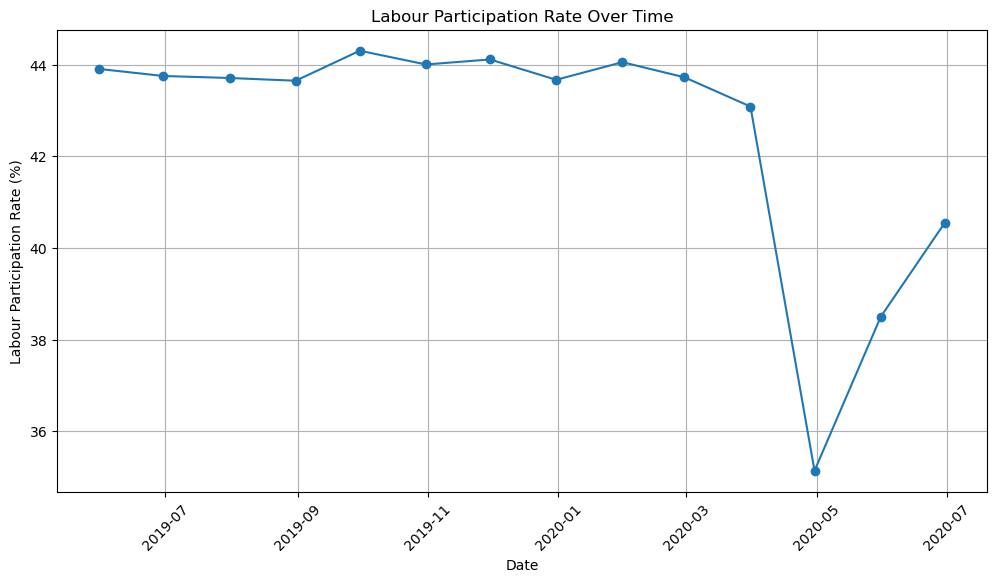

In [17]:
labour = (df.groupby("Date")["Estimated Labour Participation Rate (%)"].mean().reset_index())

plt.figure(figsize=(12,6))
plt.plot(labour["Date"],labour["Estimated Labour Participation Rate (%)"],marker="o")

plt.title("Labour Participation Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Labour Participation Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Correlation Analysis

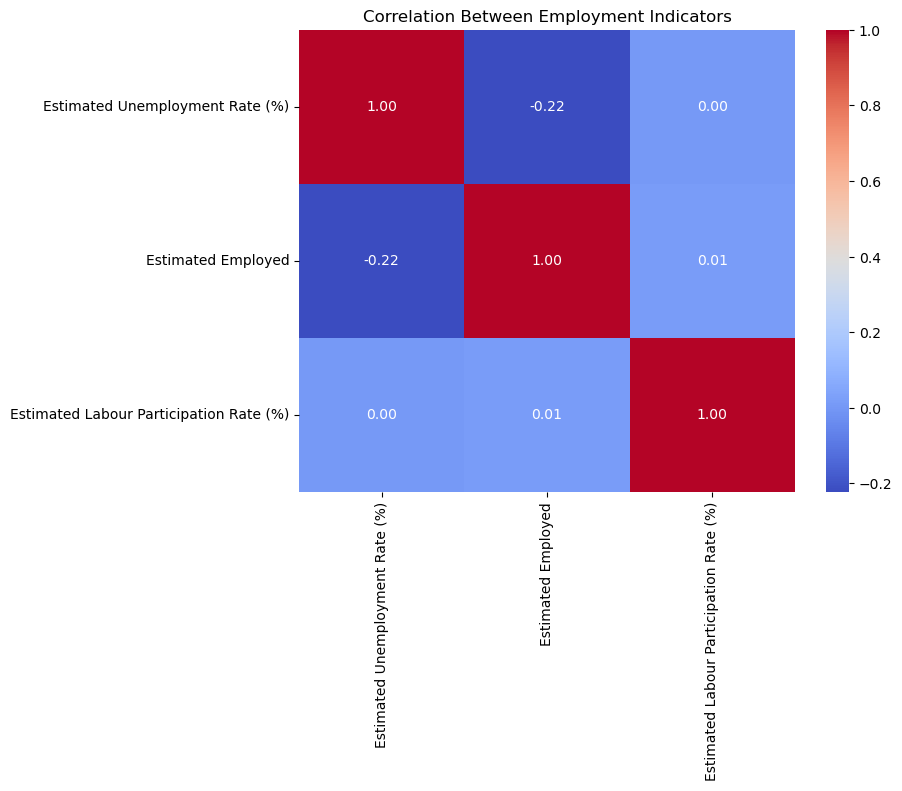

In [18]:
numeric_cels = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation = df[numeric_cels].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Employment Indicators")

plt.show()

### Seasonal trend

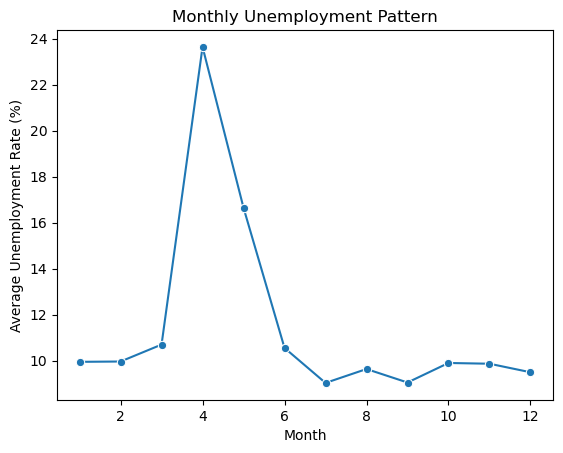

In [19]:
df["Month"] = df["Date"].dt.month

monthly_pattern = (df.groupby("Month")["Estimated Unemployment Rate (%)"].mean().reset_index())

plt.Figure(figsize=(10,5))

sns.lineplot(
    data =monthly_pattern,
    x="Month",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Monthly Unemployment Pattern")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()